# Coursework Questions 1-5

This notebook combines `q1.py` to `q5.py` into a single `.ipynb` file.
In the current version, each question prepares its own data and methods, without directly calling question-specific functions across sections.


## Question 1


In [1]:
from __future__ import annotations

import importlib.util
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import scipy.io as sio

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt

In [2]:
try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()
COVID_CLASSES = ["CT_COVID", "CT_NonCOVID"]
COVID_ROOT = Path("cw3_b")
HELPER_PATH = ROOT / "cw3_a" / "help_functions.py"
RESIZED_PICKLE = ROOT / "covid_ct_120x120px.pkl"


def load_data(path):
    data = sio.loadmat(path)
    return data["suturing"]


def clean_trial(trial):
    if trial is None or trial.size == 0:
        return None
    if np.isnan(trial).any():
        trial = trial[~np.isnan(trial).any(axis=1)]
    return trial


def clean_dataset(suturing):
    cleaned = [[None for _ in range(5)] for _ in range(8)]
    for i in range(8):
        for j in range(5):
            cleaned[i][j] = clean_trial(suturing[i, j])
    return cleaned


def import_module_from_path(module_name, path):
    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Unable to load module from {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


def ensure_resized_covid_dataset():
    if RESIZED_PICKLE.exists():
        return RESIZED_PICKLE
    helper_module = import_module_from_path("cw3_help_functions", HELPER_PATH)
    helper_module.resize_all(
        src=str(COVID_ROOT),
        pklname=str(ROOT / "covid_ct"),
        include=set(COVID_CLASSES),
        width=120,
        height=120,
    )
    return RESIZED_PICKLE


def load_covid_dataset(drop_last_non_covid=0):
    dataset = joblib.load(ensure_resized_covid_dataset())
    images = np.asarray(dataset["data"], dtype=np.float32)
    labels = np.asarray([1 if str(label).startswith("CT_COVID") else 0 for label in dataset["label"]], dtype=int)
    filenames = np.asarray(dataset["filename"])
    label_names = np.asarray(dataset["label"]).astype(str)

    if drop_last_non_covid > 0:
        covid_idx = np.where(labels == 1)[0]
        non_covid_idx = np.where(labels == 0)[0]
        keep_idx = np.sort(np.concatenate([covid_idx, non_covid_idx[:-drop_last_non_covid]]))
        images = images[keep_idx]
        labels = labels[keep_idx]
        filenames = filenames[keep_idx]
        label_names = label_names[keep_idx]

    return images, labels, filenames, label_names


In [3]:
JIGSAWS_PATH = Path("cw3_a/jigsaw_matlab.mat")
PARTICIPANTS = list("BCDEFGHI")
EXPERTS = {"C", "D", "E", "F"}

TRIAL_COLUMNS = {
    "psm1_pos": slice(38, 41),
    "psm1_rot": slice(41, 50),
    "psm1_lin_vel": slice(50, 53),
    "psm1_rot_vel": slice(53, 56),
    "psm2_pos": slice(57, 60),
    "psm2_rot": slice(60, 69),
    "psm2_lin_vel": slice(69, 72),
    "psm2_rot_vel": slice(72, 75),
}

# Q1 requires all 22 kinematic parameters to be presented as 8x5 arrays.
PARAMETER_ORDER = [
    "time_completion",
    "psm1_path_length",
    "psm2_path_length",
    "psm1_economy_area_xy",
    "psm2_economy_area_xy",
    "psm1_economy_area_xz",
    "psm2_economy_area_xz",
    "psm1_economy_area_yz",
    "psm2_economy_area_yz",
    "psm1_economy_volume",
    "psm2_economy_volume",
    "psm1_avg_linear_velocity",
    "psm2_avg_linear_velocity",
    "psm1_avg_linear_acceleration",
    "psm2_avg_linear_acceleration",
    "psm1_avg_rotational_velocity",
    "psm2_avg_rotational_velocity",
    "psm1_avg_rotational_acceleration",
    "psm2_avg_rotational_acceleration",
    "psm1_motion_smoothness",
    "psm2_motion_smoothness",
    "avg_inter_tool_distance",
]


@dataclass
class TrialMeta:
    participant: str
    trial_index: int
    label: int
    label_name: str

# path length
def compute_path_length(positions: np.ndarray) -> float:
    if len(positions) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1)))


def compute_average_magnitude(values: np.ndarray) -> float:
    if values.size == 0:
        return 0.0
    return float(np.mean(np.linalg.norm(values, axis=1)))


def compute_derivative(values: np.ndarray) -> np.ndarray:
    if len(values) < 2:
        return np.zeros_like(values)
    return np.gradient(values, axis=0)


# economy measure
def compute_economy_measure(positions: np.ndarray, dims: tuple[int, ...], path_length: float) -> float:
    if positions.size == 0 or path_length == 0:
        return 0.0
    spans = [float(np.max(positions[:, dim]) - np.min(positions[:, dim])) for dim in dims]
    return float(np.prod(spans) / path_length)


# smoothness / jerk
def compute_motion_smoothness(positions: np.ndarray, time_completion: float, path_length: float) -> float:
    if len(positions) < 4 or time_completion == 0 or path_length == 0:
        return 0.0
    velocity = compute_derivative(positions)
    acceleration = compute_derivative(velocity)
    jerk = compute_derivative(acceleration)
    jerk_sq_sum = np.sum(np.sum(jerk**2, axis=1))
    return float(np.sqrt(0.5 * (time_completion**5 / path_length**2) * jerk_sq_sum))


# Compute all parameters required for one single suturing trial.
def compute_trial_features(trial: np.ndarray) -> dict[str, float]:
    time_completion = float(max(len(trial) - 1, 0))
    psm1_pos = trial[:, TRIAL_COLUMNS["psm1_pos"]]
    psm2_pos = trial[:, TRIAL_COLUMNS["psm2_pos"]]
    psm1_lin_vel = trial[:, TRIAL_COLUMNS["psm1_lin_vel"]]
    psm2_lin_vel = trial[:, TRIAL_COLUMNS["psm2_lin_vel"]]
    psm1_rot_vel = trial[:, TRIAL_COLUMNS["psm1_rot_vel"]]
    psm2_rot_vel = trial[:, TRIAL_COLUMNS["psm2_rot_vel"]]

    psm1_path_length = compute_path_length(psm1_pos)
    psm2_path_length = compute_path_length(psm2_pos)
    psm1_lin_acc = compute_derivative(psm1_lin_vel)
    psm2_lin_acc = compute_derivative(psm2_lin_vel)
    psm1_rot_acc = compute_derivative(psm1_rot_vel)
    psm2_rot_acc = compute_derivative(psm2_rot_vel)

    return {
        "time_completion": time_completion,
        "psm1_path_length": psm1_path_length,
        "psm2_path_length": psm2_path_length,
        "psm1_economy_area_xy": compute_economy_measure(psm1_pos, (0, 1), psm1_path_length),
        "psm2_economy_area_xy": compute_economy_measure(psm2_pos, (0, 1), psm2_path_length),
        "psm1_economy_area_xz": compute_economy_measure(psm1_pos, (0, 2), psm1_path_length),
        "psm2_economy_area_xz": compute_economy_measure(psm2_pos, (0, 2), psm2_path_length),
        "psm1_economy_area_yz": compute_economy_measure(psm1_pos, (1, 2), psm1_path_length),
        "psm2_economy_area_yz": compute_economy_measure(psm2_pos, (1, 2), psm2_path_length),
        "psm1_economy_volume": compute_economy_measure(psm1_pos, (0, 1, 2), psm1_path_length),
        "psm2_economy_volume": compute_economy_measure(psm2_pos, (0, 1, 2), psm2_path_length),
        "psm1_avg_linear_velocity": compute_average_magnitude(psm1_lin_vel),
        "psm2_avg_linear_velocity": compute_average_magnitude(psm2_lin_vel),
        "psm1_avg_linear_acceleration": compute_average_magnitude(psm1_lin_acc),
        "psm2_avg_linear_acceleration": compute_average_magnitude(psm2_lin_acc),
        "psm1_avg_rotational_velocity": compute_average_magnitude(psm1_rot_vel),
        "psm2_avg_rotational_velocity": compute_average_magnitude(psm2_rot_vel),
        "psm1_avg_rotational_acceleration": compute_average_magnitude(psm1_rot_acc),
        "psm2_avg_rotational_acceleration": compute_average_magnitude(psm2_rot_acc),
        "psm1_motion_smoothness": compute_motion_smoothness(
            psm1_pos, time_completion, psm1_path_length
        ),
        "psm2_motion_smoothness": compute_motion_smoothness(
            psm2_pos, time_completion, psm2_path_length
        ),
        "avg_inter_tool_distance": compute_average_magnitude(psm1_pos - psm2_pos),
    }


def load_suturing_trials() -> list[tuple[TrialMeta, np.ndarray]]:
    data = clean_dataset(load_data(JIGSAWS_PATH))
    trials: list[tuple[TrialMeta, np.ndarray]] = []
    for participant_idx, participant in enumerate(PARTICIPANTS):
        for trial_idx in range(5):
            trial = data[participant_idx][trial_idx]
            label_name = "expert" if participant in EXPERTS else "novice"
            meta = TrialMeta(
                participant=participant,
                trial_index=trial_idx + 1,
                label=1 if participant in EXPERTS else 0,
                label_name=label_name,
            )
            trials.append((meta, trial))
    return trials


# Combine all trials into one table before splitting each parameter into 8x5 arrays.
def build_q1_feature_table() -> pd.DataFrame:
    rows = []
        # trial loop
    for meta, trial in load_suturing_trials():
        row = compute_trial_features(trial)
        row.update(
            {
                "participant": meta.participant,
                "trial_index": meta.trial_index,
                "label": meta.label,
                "label_name": meta.label_name,
            }
        )
        rows.append(row)
    columns = ["participant", "trial_index", "label", "label_name", *PARAMETER_ORDER]
    return pd.DataFrame(rows)[columns]

# Build one row per trial, then reshape each parameter into an 8x5 table.
feature_df = build_q1_feature_table()
print("Q1 parameter arrays:\n")
# 22 parameter arrays
for parameter in PARAMETER_ORDER:
    array_8x5 = (
        feature_df.pivot(index="participant", columns="trial_index", values=parameter)
        .loc[PARTICIPANTS, [1, 2, 3, 4, 5]]
        .round(6)
    )
    print(f"[{parameter}]")
    print(array_8x5.to_string())
    print()


Q1 parameter arrays:

[time_completion]
trial_index       1       2       3       4       5
participant                                        
B            5634.0  3444.0  3431.0  3256.0  2847.0
C            3179.0  3266.0  3160.0  2478.0  2576.0
D            2799.0  2213.0  2316.0  2741.0  1778.0
E            3592.0  2947.0  2604.0  2925.0  2482.0
F            2837.0  2374.0  2264.0  2372.0  2038.0
G            9011.0  3378.0  5210.0  2649.0  2453.0
H            5653.0  1492.0  3394.0  4093.0  3435.0
I            4315.0  4411.0  4283.0  3729.0  3772.0

[psm1_path_length]
trial_index         1         2         3         4         5
participant                                                  
B            1.826314  0.947776  0.777680  0.877011  1.011184
C            1.333282  1.166009  1.088015  1.044842  1.016853
D            1.171479  1.096086  1.360955  1.696628  0.984408
E            0.745531  0.723481  0.634698  0.748855  0.562240
F            1.080666  0.755255  0.846444  0.809

## Q1 Analysis

Based on the results of the `22` kinematic parameters, `Time of Completion (T)`, `Average Linear Velocity (LV)`, and `Motion Smoothness (MS)` are the most effective for distinguishing `expert` and `novice` surgeons.

The results show that experts usually complete the task faster, move at higher average speed, and perform smoother motions. In contrast, novices take longer to finish the task and show greater motion fluctuation. Therefore, `T`, `LV`, and `MS` are the most suitable input features for the later classification task.


## Question 2


In [4]:
JIGSAWS_PATH = Path("cw3_a/jigsaw_matlab.mat")
PARTICIPANT_ORDER = ["B", "C", "D", "E", "F", "G", "H", "I"]
EXPERTS = {"C", "D", "E", "F"}
TRIAL_COLUMNS = {
    "psm1_pos": slice(38, 41),
    "psm1_lin_vel": slice(50, 53),
    "psm2_pos": slice(57, 60),
    "psm2_lin_vel": slice(69, 72),
}

# Features chosen from Q1 as the most useful inputs for skill classification.
SUITABLE_FEATURES = [
    "time_completion",
    "psm1_avg_linear_velocity",
    "psm2_avg_linear_velocity",
    "psm1_motion_smoothness",
    "psm2_motion_smoothness",
]


def compute_metrics(y_true, y_pred, positive_label=1) -> dict:
    tp = int(np.sum((y_true == positive_label) & (y_pred == positive_label)))
    fp = int(np.sum((y_true != positive_label) & (y_pred == positive_label)))
    fn = int(np.sum((y_true == positive_label) & (y_pred != positive_label)))
    accuracy = float(np.mean(y_true == y_pred))
    precision = 0.0 if tp + fp == 0 else float(tp / (tp + fp))
    f1_score = 0.0 if 2 * tp + fp + fn == 0 else float((2 * tp) / (2 * tp + fp + fn))
    return {"accuracy": accuracy, "precision": precision, "f1_score": f1_score}


# LOSO leaves out the same trial index from every surgeon in each fold.
class LOSOSplitter:
    def split(self, X, y=None, groups=None):
        trial_indices = np.asarray(groups)
        for held_out_trial in sorted(np.unique(trial_indices)):
            test_idx = np.where(trial_indices == held_out_trial)[0]
            train_idx = np.where(trial_indices != held_out_trial)[0]
            yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        if groups is None:
            return 5
        return len(np.unique(groups))


# path length
def compute_path_length(positions: np.ndarray) -> float:
    if len(positions) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1)))


# smoothness
def compute_motion_smoothness(positions: np.ndarray, time_completion: float, path_length: float) -> float:
    if len(positions) < 4 or time_completion == 0 or path_length == 0:
        return 0.0
    velocity = np.gradient(positions, axis=0)
    acceleration = np.gradient(velocity, axis=0)
    jerk = np.gradient(acceleration, axis=0)
    jerk_sq_sum = np.sum(np.sum(jerk**2, axis=1))
    return float(np.sqrt(0.5 * (time_completion**5 / path_length**2) * jerk_sq_sum))

# Run nested validation: inner grid search for tuning, outer LOSO for final evaluation.
def evaluate_model(name: str, estimator, param_grid, X, y, groups) -> tuple[dict, np.ndarray, list[dict], dict]:
    outer_cv = LOSOSplitter()
    predictions = np.zeros_like(y)
    per_fold_params: list[dict] = []

        # outer LOSO
    for train_idx, test_idx in outer_cv.split(X, y, groups):
        inner_groups = groups[train_idx]
        inner_cv = LOSOSplitter()
                # inner grid search
        search = GridSearchCV(clone(estimator), param_grid=param_grid, scoring="accuracy", cv=inner_cv, n_jobs=1)
        search.fit(X[train_idx], y[train_idx], groups=inner_groups)
        best_estimator = search.best_estimator_
        predictions[test_idx] = best_estimator.predict(X[test_idx])
        per_fold_params.append(search.best_params_)

    metrics = compute_metrics(y, predictions, positive_label=1)
    representative_params = Counter(
        ", ".join(f"{key}={value}" for key, value in sorted(params.items()))
        for params in per_fold_params
    ).most_common(1)[0][0]
    return metrics, predictions, per_fold_params, {"most_common_best_params": representative_params}


data = clean_dataset(load_data(JIGSAWS_PATH))
rows_local = []
# feature extraction
for participant_idx, participant in enumerate(PARTICIPANT_ORDER):
    for trial_idx in range(5):
        trial = data[participant_idx][trial_idx]
        time_completion = float(max(len(trial) - 1, 0))
        psm1_pos = trial[:, TRIAL_COLUMNS["psm1_pos"]]
        psm2_pos = trial[:, TRIAL_COLUMNS["psm2_pos"]]
        psm1_lin_vel = trial[:, TRIAL_COLUMNS["psm1_lin_vel"]]
        psm2_lin_vel = trial[:, TRIAL_COLUMNS["psm2_lin_vel"]]
        psm1_path_length = compute_path_length(psm1_pos)
        psm2_path_length = compute_path_length(psm2_pos)
        rows_local.append(
            {
                "participant": participant,
                "trial_index": trial_idx + 1,
                "label": 1 if participant in EXPERTS else 0,
                "time_completion": time_completion,
                "psm1_avg_linear_velocity": (
                    float(np.mean(np.linalg.norm(psm1_lin_vel, axis=1))) if psm1_lin_vel.size else 0.0
                ),
                "psm2_avg_linear_velocity": (
                    float(np.mean(np.linalg.norm(psm2_lin_vel, axis=1))) if psm2_lin_vel.size else 0.0
                ),
                "psm1_motion_smoothness": compute_motion_smoothness(
                    psm1_pos, time_completion, psm1_path_length
                ),
                "psm2_motion_smoothness": compute_motion_smoothness(
                    psm2_pos, time_completion, psm2_path_length
                ),
            }
        )
# Convert the handcrafted trial features into the design matrix used by the classifiers.
feature_df = pd.DataFrame(rows_local)
X = feature_df[SUITABLE_FEATURES].to_numpy(dtype=float)
y = feature_df["label"].to_numpy(dtype=int)
groups = feature_df["trial_index"].to_numpy(dtype=int)

# Q2 compares the three classifiers explicitly required in the coursework.
estimators = {
    "bagging_dt": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42,
    ),
    "random_forest": RandomForestClassifier(random_state=42),
    "knn": KNeighborsClassifier(),
}
grids = {
    "bagging_dt": {
        "n_estimators": [10, 25, 50, 100],
        "estimator__criterion": ["gini"],
        "estimator__max_depth": [None, 3, 5, 7],
    },
    "random_forest": {
        "n_estimators": [10, 25, 50, 100, 200],
        "criterion": ["entropy"],
    },
    "knn": {
        "n_neighbors": [1, 3, 5, 7, 9],
        "metric": ["euclidean", "manhattan", "minkowski"],
    },
}
structures = {
    "bagging_dt": "BaggingClassifier(estimator=DecisionTreeClassifier(criterion='gini'))",
    "random_forest": "RandomForestClassifier(criterion='entropy')",
    "knn": "KNeighborsClassifier()",
}
rows = [["Model", "Accuracy", "Precision", "F1", "Representative Best Params"]]
results = {}

# model comparison
for name, estimator in estimators.items():
    metrics, predictions, per_fold_params, summary = evaluate_model(name, estimator, grids[name], X, y, groups)
    rows.append(
        [
            name,
            f"{metrics['accuracy']:.4f}",
            f"{metrics['precision']:.4f}",
            f"{metrics['f1_score']:.4f}",
            summary["most_common_best_params"],
        ]
    )
    results[name] = predictions

print("\nQ2 classifier structures:")
for name, structure in structures.items():
    print(f"{name}: {structure}")
print("\nQ2 evaluation metrics:\n")
print(pd.DataFrame(rows[1:], columns=rows[0]).to_string(index=False))
print("\nQ2 confusion matrices:\n")
for name in estimators:
    matrix = pd.DataFrame(
        confusion_matrix(y, results[name], labels=[0, 1]),
        index=["true_novice", "true_expert"],
        columns=["pred_novice", "pred_expert"],
    )
    print(f"[{name}]")
    print(matrix.to_string())
    print()



Q2 classifier structures:
bagging_dt: BaggingClassifier(estimator=DecisionTreeClassifier(criterion='gini'))
random_forest: RandomForestClassifier(criterion='entropy')
knn: KNeighborsClassifier()

Q2 evaluation metrics:

        Model Accuracy Precision     F1                                            Representative Best Params
   bagging_dt   0.8250    0.8421 0.8205 estimator__criterion=gini, estimator__max_depth=None, n_estimators=10
random_forest   0.8500    0.8182 0.8571                                    criterion=entropy, n_estimators=10
          knn   0.7500    0.7500 0.7500                                       metric=euclidean, n_neighbors=5

Q2 confusion matrices:

[bagging_dt]
             pred_novice  pred_expert
true_novice           17            3
true_expert            4           16

[random_forest]
             pred_novice  pred_expert
true_novice           16            4
true_expert            2           18

[knn]
             pred_novice  pred_expert
true_novice

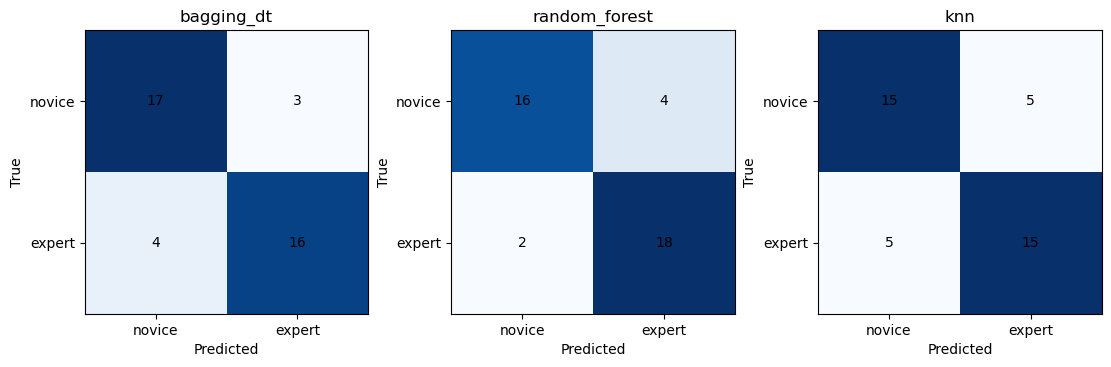

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
for ax, name in zip(axes, ["bagging_dt", "random_forest", "knn"]):
    _, predictions, _, _ = evaluate_model(name, estimators[name], grids[name], X, y, groups)
    cm = confusion_matrix(y, predictions, labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["novice", "expert"])
    ax.set_yticklabels(["novice", "expert"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_aspect("equal")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.show()


## Q2 Classification Results

In this question, `Time of Completion (T)`, `Average Linear Velocity (LV)`, and `Motion Smoothness (MS)` were selected from Q1 as the input features, because these parameters showed the clearest differences between experts and novices. Following the coursework requirement, `LOSO (Leave-One-SuperTrial-Out)` cross-validation was used for evaluation.

The classifiers developed were:

- `Bagging Decision Tree`: `BaggingClassifier(estimator=DecisionTreeClassifier(criterion='gini'))`
- `Random Forest`: `RandomForestClassifier(criterion='entropy')`
- `KNN`: `KNeighborsClassifier()`

The optimised results are:

- `Bagging Decision Tree`: Accuracy = `0.8250`, Precision = `0.8421`, F1 = `0.8205`
- `Random Forest`: Accuracy = `0.8500`, Precision = `0.8182`, F1 = `0.8571`
- `KNN`: Accuracy = `0.7500`, Precision = `0.7500`, F1 = `0.7500`

The corresponding best parameters are:

- `Bagging Decision Tree`: `criterion=gini`, `max_depth=None`, `n_estimators=10`
- `Random Forest`: `criterion=entropy`, `n_estimators=10`
- `KNN`: `metric=euclidean`, `n_neighbors=5`

From the results, `Random Forest` performs best, achieving the highest accuracy and F1 score. `Bagging Decision Tree` ranks second, while `KNN` gives the weakest classification performance.


## Question 3


In [6]:
def compute_metrics(y_true, y_pred, positive_label=1):
    tp = int(np.sum((y_true == positive_label) & (y_pred == positive_label)))
    fp = int(np.sum((y_true != positive_label) & (y_pred == positive_label)))
    fn = int(np.sum((y_true == positive_label) & (y_pred != positive_label)))
    accuracy = float(np.mean(y_true == y_pred))
    precision = 0.0 if tp + fp == 0 else float(tp / (tp + fp))
    f1_score = 0.0 if 2 * tp + fp + fn == 0 else float((2 * tp) / (2 * tp + fp + fn))
    return {"accuracy": accuracy, "precision": precision, "f1_score": f1_score}


# Apply the same 5-fold evaluation pipeline to both LDA and QDA.
def cross_validated_predict(estimator, X, y):
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    predictions = np.zeros_like(y)
    fold_sizes = []

    # 5-fold split
    for train_idx, test_idx in outer_cv.split(X, y):
        fitted_estimator = clone(estimator)
        fitted_estimator.fit(X[train_idx], y[train_idx])
        predictions[test_idx] = fitted_estimator.predict(X[test_idx])
        fold_sizes.append(len(test_idx))

    return {
        "metrics": compute_metrics(y, predictions, positive_label=1),
        "predictions": predictions,
        "fold_sizes": fold_sizes,
    }


def run_discriminant_analysis(images, labels):
    # LDA pipeline
    lda_pipeline = Pipeline(
        [
            ("flatten", FunctionTransformer(lambda images: images.reshape(images.shape[0], -1), validate=False)),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=40, svd_solver="randomized", random_state=42)),
            ("clf", LinearDiscriminantAnalysis(solver="svd")),
        ]
    )
    # QDA pipeline
    qda_pipeline = Pipeline(
        [
            ("flatten", FunctionTransformer(lambda images: images.reshape(images.shape[0], -1), validate=False)),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=20, svd_solver="randomized", random_state=42)),
            ("clf", QuadraticDiscriminantAnalysis(reg_param=0.1)),
        ]
    )

    lda_results = cross_validated_predict(lda_pipeline, images, labels)
    qda_results = cross_validated_predict(qda_pipeline, images, labels)
    lda_results["representative_params"] = "clf__solver=svd, pca__n_components=40"
    qda_results["representative_params"] = "clf__reg_param=0.1, pca__n_components=20"
    return {"LDA": lda_results, "QDA": qda_results}


# dataset load
images, labels, _, _ = load_covid_dataset()
results = run_discriminant_analysis(images, labels)

rows = []
# metric table
for model_name, result in results.items():
    rows.append(
        {
            "Model": model_name,
            "Accuracy": f"{result['metrics']['accuracy']:.4f}",
            "Precision": f"{result['metrics']['precision']:.4f}",
            "F1": f"{result['metrics']['f1_score']:.4f}",
            "Representative Best Params": result["representative_params"],
        }
    )

fold_sizes = results["LDA"]["fold_sizes"]
print("Q3 dataset summary:")
print(f"images={len(images)}, covid={np.sum(labels == 1)}, non_covid={np.sum(labels == 0)}")
print(f"class balance: covid={np.mean(labels == 1):.1%}, non_covid={np.mean(labels == 0):.1%}")
print(f"fold sizes: {fold_sizes}")
print()
print("Q3 evaluation metrics:")
print()
print(pd.DataFrame(rows).to_string(index=False))
print()
print("Q3 confusion matrices:")
print()
for model_name, result in results.items():
    matrix = pd.DataFrame(
        confusion_matrix(labels, result["predictions"], labels=[0, 1]),
        index=["true_non_covid", "true_covid"],
        columns=["pred_non_covid", "pred_covid"],
    )
    print(f"[{model_name}]")
    print(matrix.to_string())
    print()


Q3 dataset summary:
images=746, covid=349, non_covid=397
class balance: covid=46.8%, non_covid=53.2%
fold sizes: [150, 149, 149, 149, 149]

Q3 evaluation metrics:

Model Accuracy Precision     F1               Representative Best Params
  LDA   0.7198    0.7035 0.6984    clf__solver=svd, pca__n_components=40
  QDA   0.7252    0.7081 0.7050 clf__reg_param=0.1, pca__n_components=20

Q3 confusion matrices:

[LDA]
                pred_non_covid  pred_covid
true_non_covid             295         102
true_covid                 107         242

[QDA]
                pred_non_covid  pred_covid
true_non_covid             296         101
true_covid                 104         245



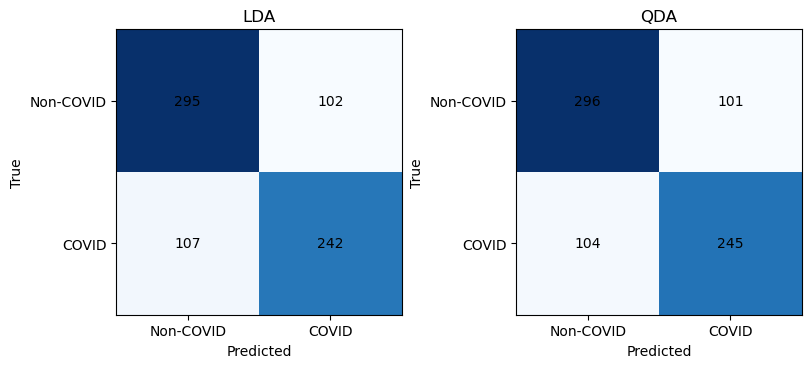

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6), constrained_layout=True)
for ax, model_name in zip(axes, ["LDA", "QDA"]):
    cm = confusion_matrix(labels, results[model_name]["predictions"], labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(model_name)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Non-COVID", "COVID"])
    ax.set_yticklabels(["Non-COVID", "COVID"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_aspect("equal")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.show()


## Q3

The COVID-19 dataset contains `746` CT images, including `349` COVID images and `397` Non-COVID images.  
This question uses `5-fold cross-validation`, with validation fold sizes of `[150, 149, 149, 149, 149]`.

Two discriminant analysis classifiers were developed:

- `LDA`
- `QDA`

Their evaluation results are:

- `LDA`: Accuracy = `0.7198`, Precision = `0.7035`, F1 = `0.6984`
- `QDA`: Accuracy = `0.7252`, Precision = `0.7081`, F1 = `0.7050`

The corresponding confusion matrices are:

`LDA`

|                | pred_non_covid | pred_covid |
| --- | ---: | ---: |
| true_non_covid | 295 | 102 |
| true_covid | 107 | 242 |

`QDA`

|                | pred_non_covid | pred_covid |
| --- | ---: | ---: |
| true_non_covid | 296 | 101 |
| true_covid | 104 | 245 |

From the results, `QDA` achieves slightly higher accuracy, precision, and F1 score than `LDA`, so `QDA` performs slightly better than `LDA` in this task.


## Question 4


In [8]:
try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()
HELPER_PATH = ROOT / "cw3_a" / "help_functions.py"


# Q3 baseline
def run_discriminant_analysis_local(images, labels):
    lda_pipeline = Pipeline(
        [
            ("flatten", FunctionTransformer(lambda imgs: imgs.reshape(imgs.shape[0], -1), validate=False)),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=40, svd_solver="randomized", random_state=42)),
            ("clf", LinearDiscriminantAnalysis(solver="svd")),
        ]
    )
    qda_pipeline = Pipeline(
        [
            ("flatten", FunctionTransformer(lambda imgs: imgs.reshape(imgs.shape[0], -1), validate=False)),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=20, svd_solver="randomized", random_state=42)),
            ("clf", QuadraticDiscriminantAnalysis(reg_param=0.1)),
        ]
    )
    results = {}
    for name, estimator in {"LDA": lda_pipeline, "QDA": qda_pipeline}.items():
        outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        predictions = np.zeros_like(labels)
        # outer 5-fold
        for train_idx, test_idx in outer_cv.split(images, labels):
            fitted = clone(estimator)
            fitted.fit(images[train_idx], labels[train_idx])
            predictions[test_idx] = fitted.predict(images[test_idx])
        results[name] = {"metrics": compute_metrics(labels, predictions, positive_label=1)}
    return results


# HoG + SVM
def evaluate_svm(images, labels, class_weight=None):
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    helper_module = import_module_from_path("cw3_help_functions_for_q4", HELPER_PATH)
    pipeline = Pipeline(
        [
            (
                "hogify",
                helper_module.HogTransformer(
                    orientations=9,
                    pixels_per_cell=(14, 14),
                    cells_per_block=(2, 2),
                    block_norm="L2-Hys",
                ),
            ),
            ("scalify", StandardScaler()),
            ("classify", SVC(class_weight=class_weight)),
        ]
    )
    # kernel search
    grid = [
        {
            "classify__kernel": ["linear"],
            "hogify__orientations": [8, 9],
            "hogify__cells_per_block": [(2, 2)],
            "hogify__pixels_per_cell": [(8, 8), (12, 12)],
            "classify__C": [0.1, 1],
        },
        {
            "classify__kernel": ["rbf"],
            "hogify__orientations": [8, 9],
            "hogify__cells_per_block": [(2, 2)],
            "hogify__pixels_per_cell": [(8, 8), (12, 12)],
            "classify__C": [0.1, 1],
            "classify__gamma": ["scale", 0.01, 0.1],
        },
    ]
    predictions = np.zeros_like(labels)
    per_fold_params = []
    fold_sizes = []

    # outer 5-fold
    for train_idx, test_idx in outer_cv.split(images, labels):
        inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
        # inner tuning
        search = GridSearchCV(clone(pipeline), grid, scoring="accuracy", cv=inner_cv, n_jobs=1)
        search.fit(images[train_idx], labels[train_idx])
        predictions[test_idx] = search.best_estimator_.predict(images[test_idx])
        per_fold_params.append(search.best_params_)
        fold_sizes.append(len(test_idx))

    representative_params = Counter(
        ", ".join(f"{key}={value}" for key, value in sorted(params.items()))
        for params in per_fold_params
    ).most_common(1)[0][0]

    return {
        "metrics": compute_metrics(labels, predictions, positive_label=1),
        "predictions": predictions,
        "representative_params": representative_params,
        "fold_sizes": fold_sizes,
    }


# balanced dataset
images, labels, _, _ = load_covid_dataset()
svm_results = evaluate_svm(images, labels)
da_results = run_discriminant_analysis_local(images, labels)
print("Q4 fold sizes:")
print(svm_results["fold_sizes"])
print()
print("Q4 SVM metrics:")
print()
print(
    pd.DataFrame(
        [
            {
                "Model": "SVM",
                "Accuracy": f"{svm_results['metrics']['accuracy']:.4f}",
                "Precision": f"{svm_results['metrics']['precision']:.4f}",
                "F1": f"{svm_results['metrics']['f1_score']:.4f}",
                "Representative Best Params": svm_results["representative_params"],
            }
        ]
    ).to_string(index=False)
)
print()
print("Q4 comparison with Q3:")
print()
print(
    pd.DataFrame(
        [
            {
                "Model": "LDA",
                "Accuracy": f"{da_results['LDA']['metrics']['accuracy']:.4f}",
                "Precision": f"{da_results['LDA']['metrics']['precision']:.4f}",
                "F1": f"{da_results['LDA']['metrics']['f1_score']:.4f}",
            },
            {
                "Model": "QDA",
                "Accuracy": f"{da_results['QDA']['metrics']['accuracy']:.4f}",
                "Precision": f"{da_results['QDA']['metrics']['precision']:.4f}",
                "F1": f"{da_results['QDA']['metrics']['f1_score']:.4f}",
            },
            {
                "Model": "SVM",
                "Accuracy": f"{svm_results['metrics']['accuracy']:.4f}",
                "Precision": f"{svm_results['metrics']['precision']:.4f}",
                "F1": f"{svm_results['metrics']['f1_score']:.4f}",
            },
        ]
    ).to_string(index=False)
)
print()
print("Q4 SVM confusion matrix:")
print()
print(
    pd.DataFrame(
        confusion_matrix(labels, svm_results["predictions"], labels=[0, 1]),
        index=["true_non_covid", "true_covid"],
        columns=["pred_non_covid", "pred_covid"],
    ).to_string()
)


Q4 fold sizes:
[150, 149, 149, 149, 149]

Q4 SVM metrics:

Model Accuracy Precision     F1                                                                                                                           Representative Best Params
  SVM   0.8097    0.8035 0.7942 classify__C=1, classify__gamma=scale, classify__kernel=rbf, hogify__cells_per_block=(2, 2), hogify__orientations=8, hogify__pixels_per_cell=(12, 12)

Q4 comparison with Q3:

Model Accuracy Precision     F1
  LDA   0.7198    0.7035 0.6984
  QDA   0.7252    0.7081 0.7050
  SVM   0.8097    0.8035 0.7942

Q4 SVM confusion matrix:

                pred_non_covid  pred_covid
true_non_covid             330          67
true_covid                  75         274


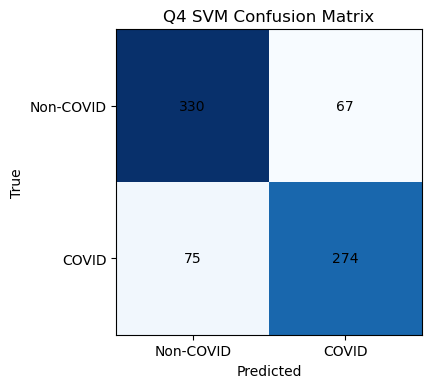

In [9]:
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, svm_results["predictions"], labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.2, 4.0), constrained_layout=True)
ax.imshow(cm, cmap="Blues")
ax.set_title("Q4 SVM Confusion Matrix")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Non-COVID", "COVID"])
ax.set_yticklabels(["Non-COVID", "COVID"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_aspect("equal")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.show()


## Q4

This question uses the `COVID-19` dataset and develops an `SVM` classifier based on `HoG` features. The model is evaluated using `5-fold cross-validation`, with fold sizes of `[150, 149, 149, 149, 149]`. Both `linear` and `rbf` kernels were considered, and `grid search` was used for parameter optimisation.

The best `SVM` parameters are:

- `kernel = rbf`
- `C = 1`
- `gamma = scale`
- `orientations = 8`
- `pixels_per_cell = (12, 12)`
- `cells_per_block = (2, 2)`

The classification results are:

- Accuracy = `0.8097`
- Precision = `0.8035`
- F1 = `0.7942`

The corresponding confusion matrix is:

|                | pred_non_covid | pred_covid |
| --- | ---: | ---: |
| true_non_covid | 330 | 67 |
| true_covid | 75 | 274 |

Compared with Q3, the `SVM` achieves higher accuracy, precision, and F1 score than both `LDA` and `QDA`.

For the comparison with the accuracy reported in references `[1]` and `[2]`, this notebook does not yet state the exact values from those papers, so they should be added before submission. Even if the reported values are higher or lower, the comparison is not fully fair because the literature and this experiment may differ in model type, feature extraction, preprocessing, and data-splitting strategy.


## Question 5


In [10]:
try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()
HELPER_PATH = ROOT / "cw3_a" / "help_functions.py"


# imbalanced SVM
def evaluate_svm_local(images, labels, class_weight=None):
    helper_module = import_module_from_path("cw3_help_functions_for_q5", HELPER_PATH)
    pipeline = Pipeline(
        [
            (
                "hogify",
                helper_module.HogTransformer(
                    orientations=9,
                    pixels_per_cell=(14, 14),
                    cells_per_block=(2, 2),
                    block_norm="L2-Hys",
                ),
            ),
            ("scalify", StandardScaler()),
            ("classify", SVC(kernel="linear", class_weight=class_weight)),
        ]
    )
    # parameter search
    grid = [
        {
            "hogify__orientations": [8, 9],
            "hogify__cells_per_block": [(2, 2)],
            "hogify__pixels_per_cell": [(8, 8), (12, 12)],
            "classify__C": [0.1, 1],
        }
    ]
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    predictions = np.zeros_like(labels)
    per_fold_params = []
    fold_sizes = []

    # outer 5-fold
    for train_idx, test_idx in outer_cv.split(images, labels):
        inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
        # inner tuning
        search = GridSearchCV(clone(pipeline), grid, scoring="accuracy", cv=inner_cv, n_jobs=1)
        search.fit(images[train_idx], labels[train_idx])
        predictions[test_idx] = search.best_estimator_.predict(images[test_idx])
        per_fold_params.append(search.best_params_)
        fold_sizes.append(len(test_idx))

    representative_params = Counter(
        ", ".join(f"{key}={value}" for key, value in sorted(params.items()))
        for params in per_fold_params
    ).most_common(1)[0][0]
    return {
        "metrics": compute_metrics(labels, predictions, positive_label=1),
        "predictions": predictions,
        "representative_params": representative_params,
        "fold_sizes": fold_sizes,
    }


# class imbalance
imbalanced_images, imbalanced_labels, _, _ = load_covid_dataset(drop_last_non_covid=200)
# baseline
baseline_results = evaluate_svm_local(imbalanced_images, imbalanced_labels)
# class weighting
balanced_weight_results = evaluate_svm_local(
    imbalanced_images,
    imbalanced_labels,
    class_weight="balanced",
)

# results table
rows = [
    {
        "Setting": "Imbalanced dataset",
        "Accuracy": f"{baseline_results['metrics']['accuracy']:.4f}",
        "Precision": f"{baseline_results['metrics']['precision']:.4f}",
        "F1": f"{baseline_results['metrics']['f1_score']:.4f}",
        "Representative Best Params": baseline_results["representative_params"],
    },
    {
        "Setting": "Imbalanced + class_weight=balanced",
        "Accuracy": f"{balanced_weight_results['metrics']['accuracy']:.4f}",
        "Precision": f"{balanced_weight_results['metrics']['precision']:.4f}",
        "F1": f"{balanced_weight_results['metrics']['f1_score']:.4f}",
        "Representative Best Params": balanced_weight_results["representative_params"],
    },
]
print("Q5 dataset summary:")
print(f"imbalanced images={len(imbalanced_images)}, covid={np.sum(imbalanced_labels == 1)}, non_covid={np.sum(imbalanced_labels == 0)}")
print(f"fold sizes: {baseline_results['fold_sizes']}")
print()
print("Q5 evaluation metrics:")
print()
print(pd.DataFrame(rows).to_string(index=False))
print()
print("Q5 confusion matrices:")
print()
for name, predictions in [
    ("imbalanced", baseline_results["predictions"]),
    ("imbalanced + class_weight=balanced", balanced_weight_results["predictions"]),
]:
    matrix = pd.DataFrame(
        confusion_matrix(imbalanced_labels, predictions, labels=[0, 1]),
        index=["true_non_covid", "true_covid"],
        columns=["pred_non_covid", "pred_covid"],
    )
    print(f"[{name}]")
    print(matrix.to_string())
    print()


Q5 dataset summary:
imbalanced images=546, covid=349, non_covid=197
fold sizes: [110, 109, 109, 109, 109]

Q5 evaluation metrics:

                           Setting Accuracy Precision     F1                                                                              Representative Best Params
                Imbalanced dataset   0.7912    0.8255 0.8394 classify__C=0.1, hogify__cells_per_block=(2, 2), hogify__orientations=9, hogify__pixels_per_cell=(8, 8)
Imbalanced + class_weight=balanced   0.7912    0.8255 0.8394 classify__C=0.1, hogify__cells_per_block=(2, 2), hogify__orientations=9, hogify__pixels_per_cell=(8, 8)

Q5 confusion matrices:

[imbalanced]
                pred_non_covid  pred_covid
true_non_covid             134          63
true_covid                  51         298

[imbalanced + class_weight=balanced]
                pred_non_covid  pred_covid
true_non_covid             134          63
true_covid                  51         298



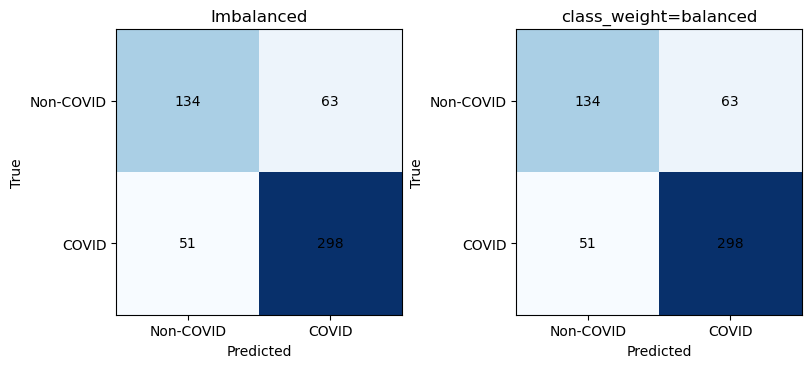

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6), constrained_layout=True)
for ax, name, preds in zip(
    axes,
    ["Imbalanced", "class_weight=balanced"],
    [baseline_results["predictions"], balanced_weight_results["predictions"]],
):
    cm = confusion_matrix(imbalanced_labels, preds, labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Non-COVID", "COVID"])
    ax.set_yticklabels(["Non-COVID", "COVID"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_aspect("equal")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.show()


## Q5

In this question, the dataset was rearranged into an imbalanced version containing `546` CT images, including `349` COVID images and `197` Non-COVID images. The same `SVM` method as in Q4 was then applied, using `5-fold cross-validation` with fold sizes of `[110, 109, 109, 109, 109]`.

Without handling class imbalance, the classification results are:

- Accuracy = `0.7912`
- Precision = `0.8255`
- F1 = `0.8394`

The corresponding confusion matrix is:

|                | pred_non_covid | pred_covid |
| --- | ---: | ---: |
| true_non_covid | 134 | 63 |
| true_covid | 51 | 298 |

After applying `class_weight = balanced` to reduce the effect of class imbalance, the results are:

- Accuracy = `0.7912`
- Precision = `0.8255`
- F1 = `0.8394`

The corresponding confusion matrix is:

|                | pred_non_covid | pred_covid |
| --- | ---: | ---: |
| true_non_covid | 134 | 63 |
| true_covid | 51 | 298 |

Compared with the balanced dataset result in Q4, the SVM accuracy in Q4 was `0.8097`, whereas the accuracy in Q5 on the imbalanced dataset was `0.7912`, indicating that class imbalance reduced classification performance.

In this question, `class_weight = balanced` was used as the method to reduce the impact of imbalance. However, the results before and after mitigation are identical, which suggests that under the current feature set and parameter setting, this method did not provide a noticeable improvement.
